# 002 EDA & Construcción del Dataset (centro x semana)

Este notebook implementa la **Fase 0 y Fase 1** según el plan de construcción del dataset `002-eda-dataset/plan.md`.

## T01: Importación de Parámetros

In [1]:
import pandas as pd
import numpy as np
import sys
import os

sys.path.append(r"c:\Proyectos\Diplomado-ML V2")
from configuraciones.configuraciones import (
    DEIS_PARQUET,
    PANEL_PARQUET,
    REGION_CODIGO_RM,
    COMUNAS_ESCENARIO_A,
    ANIO_INICIO,
    ANIO_FIN,
    ORDENCAUSA_TARGET,
    GRUPOS_EDAD_PREDICTORES,
    K_SIGMA,
    VENTANA_BASE,
    MAD_SCALE,
    RADIO_VECINDAD_KM,
    FLUNET_CSV,
    FLUNET_ORIGIN_SOURCE
)

## T02: Carga Cruda + Perfil

In [2]:
print(f"Cargando dataset desde: {DEIS_PARQUET}")
df_raw = pd.read_parquet(DEIS_PARQUET)

print(f"Total de filas: {len(df_raw):,}")

# Valores nulos
print("\nNulos por columna:")
display(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

# Rangos de años
print("\nRangos de años:")
display(df_raw['Anio'].value_counts().sort_index())

# Rango de semanas
print(f"\nSemanas estadísticas: {df_raw['SemanaEstadistica'].min()} a {df_raw['SemanaEstadistica'].max()}")

Cargando dataset desde: c:\Proyectos\Diplomado-ML V2\dataset_salud\at_urg_respiratorio_semanal.parquet


Total de filas: 3,564,748

Nulos por columna:


EstablecimientoCodigo        25710
EstablecimientoGlosa         25710
RegionCodigo                 25710
RegionGlosa                  25710
ComunaCodigo                 25710
ComunaGlosa                  25710
ServicioSaludCodigo          25710
ServicioSaludGlosa           25710
TipoEstablecimiento          25710
DependenciaAdministrativa    25710
NivelAtencion                25710
TipoUrgencia                 25710
Latitud                      25710
Longitud                     25710
NivelComplejidad             25710
dtype: int64


Rangos de años:


Anio
2014    176304
2015    184976
2016    185248
2017    186424
2018    187328
2019    192938
2020    325154
2021    377244
2022    379128
2023    381120
2024    384828
2025    401784
2026    202272
Name: count, dtype: int64


Semanas estadísticas: 1 a 53


## T03: Filtrado (Escenario A)

Filtrando por región 13, comunas del Escenario A y periodo 2023-2026. Excluyendo nulos y parseando coordenadas.

In [3]:
import unicodedata

def normalize_text(text):
    if pd.isna(text): return text
    text = str(text).upper().strip()
    text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    return text

# 1. Filtrar Región 13 y Años 2023-2026
df = df_raw[
    (df_raw['RegionCodigo'].astype(str).str.replace(r'\.0$', '', regex=True) == str(REGION_CODIGO_RM)) &
    (df_raw['Anio'].between(ANIO_INICIO, ANIO_FIN))
].copy()

# 2. Excluir filas sin EstablecimientoCodigo / comuna
df = df.dropna(subset=['EstablecimientoCodigo', 'ComunaCodigo'])

# 3. Filtrar comunas del Escenario A normalizando el texto
comunas_escenario_norm = [normalize_text(c) for c in COMUNAS_ESCENARIO_A]
df['ComunaGlosa_Norm'] = df['ComunaGlosa'].apply(normalize_text)
df = df[df['ComunaGlosa_Norm'].isin(comunas_escenario_norm)]

# 4. Parsear Latitud y Longitud
df['Latitud'] = df['Latitud'].astype(str).str.replace(',', '.').astype(float)
df['Longitud'] = df['Longitud'].astype(str).str.replace(',', '.').astype(float)

# Comprobar resultados (DoD)
n_estab = df['EstablecimientoCodigo'].nunique()
n_comunas = df['ComunaCodigo'].nunique()
n_nulos = df[['EstablecimientoCodigo', 'ComunaCodigo']].isnull().sum().sum()

print(f"Comunas únicas: {n_comunas} (Esperado: 11)")
print(f"Establecimientos únicos: {n_estab} (Esperado: ~49)")
print(f"Nulos en metadata clave: {n_nulos} (Esperado: 0)")
print(f"Tipos de Lat/Lon: {df['Latitud'].dtype}, {df['Longitud'].dtype}")

Comunas únicas: 11 (Esperado: 11)
Establecimientos únicos: 49 (Esperado: ~49)
Nulos en metadata clave: 0 (Esperado: 0)
Tipos de Lat/Lon: float64, float64


## T04 & T05: Causa-target y Panel base

Aislamiento de la causa respiratoria total (`OrdenCausa=3`) y hospitalizaciones (`OrdenCausa=33`). Creación del panel único por centro y semana.

In [4]:
# Atenciones (Target A)
df_atenciones = df[df['OrdenCausa'] == ORDENCAUSA_TARGET].copy()

# Agrupar predictores etarios
df_atenciones['n_0a4'] = df_atenciones['NumMenor1Anio'] + df_atenciones['Num1a4Anios']
df_atenciones['n_5a14'] = df_atenciones['Num5a14Anios']
df_atenciones['n_65mas'] = df_atenciones['Num65oMas']
df_atenciones = df_atenciones.rename(columns={'NumTotal': 'n_atenciones'})

# Hospitalizaciones (Sección 2, OrdenCausa=33)
df_hosp = df[df['OrdenCausa'] == 33].copy()
df_hosp = df_hosp[['EstablecimientoCodigo', 'Anio', 'SemanaEstadistica', 'NumTotal']].rename(columns={'NumTotal': 'n_hosp_resp'})

# Construir el panel unificado
keys = ['EstablecimientoCodigo', 'Anio', 'SemanaEstadistica']
attrs = df_atenciones[['EstablecimientoCodigo', 'TipoUrgencia', 'NivelComplejidad', 'ServicioSaludCodigo', 'ComunaCodigo', 'Latitud', 'Longitud']].drop_duplicates()

panel = df_atenciones[keys + ['n_atenciones', 'n_0a4', 'n_5a14', 'n_65mas']]
panel = pd.merge(panel, df_hosp, on=keys, how='left')
panel['n_hosp_resp'] = panel['n_hosp_resp'].fillna(0).astype(int)
panel = pd.merge(panel, attrs, on='EstablecimientoCodigo', how='left')

# Verificaciones (DoD)
is_unique = panel.duplicated(subset=keys).sum() == 0
print(f"Llave única en panel: {is_unique} (Esperado: True)")
print(f"Filas en panel: {len(panel)}")
display(panel.head())

Llave única en panel: True (Esperado: True)
Filas en panel: 8949


,EstablecimientoCodigo,Anio,SemanaEstadistica,n_atenciones,n_0a4,n_5a14,n_65mas,n_hosp_resp,TipoUrgencia,NivelComplejidad,ServicioSaludCodigo,ComunaCodigo,Latitud,Longitud
0,114105,2024,47,101,57,40,1,22,Urgencia Hospitalaria (UEH),Alta Complejidad,14,13110,-33.514161,-70.599148
1,113812,2023,40,268,41,71,19,0,Urgencia Ambulatoria (SAPU),Baja Complejidad,13,13105,-33.559330,-70.669491
2,200119,2024,25,124,28,24,12,0,Urgencia Ambulatoria (SAPU),Baja Complejidad,10,13601,-33.669668,-70.937885
3,114826,2023,36,447,81,130,28,0,Urgencia Ambulatoria (SAPU),Baja Complejidad,14,13201,-33.626314,-70.625363
4,114812,2025,21,512,55,112,66,0,Urgencia Ambulatoria (SAPU),Baja Complejidad,14,13201,-33.623509,-70.588615


## T06: Timeline continuo + Semanas faltantes

Generación de un índice continuo y rellenado de `n_atenciones = 0` para asegurar que el cálculo rodante considere saltos de tiempo reales.

In [5]:
# Timeline global de la región
timeline = df_raw[df_raw['Anio'].between(ANIO_INICIO, ANIO_FIN)][['Anio', 'SemanaEstadistica']].drop_duplicates().sort_values(['Anio', 'SemanaEstadistica'])
centros = panel['EstablecimientoCodigo'].unique()
timeline_tuples = [tuple(x) for x in timeline.to_numpy()]

full_idx = pd.MultiIndex.from_tuples([(c, a, s) for c in centros for (a, s) in timeline_tuples], names=keys)

# Reindexar
panel = panel.set_index(keys).reindex(full_idx).reset_index()

# Rellenar con 0
num_cols = ['n_atenciones', 'n_0a4', 'n_5a14', 'n_65mas', 'n_hosp_resp']
panel[num_cols] = panel[num_cols].fillna(0).astype(int)

# Restaurar metadata
panel = panel.drop(columns=attrs.columns.drop('EstablecimientoCodigo'), errors='ignore')
panel = pd.merge(panel, attrs, on='EstablecimientoCodigo', how='left')

print("Nulos en features tras reindexar:", panel[num_cols].isnull().sum().sum())

Nulos en features tras reindexar: 0


## T07 & T08: Targets (A y B)

Cálculo del target B (clasificación de alta demanda) asegurando *ausencia de fuga* (se hace `shift(1)` antes del cálculo rodante) y verificando el arranque en frío.

**Enmienda 2026-07-06 — línea base ROBUSTA.** Se reemplaza la media móvil ± σ de 4 semanas por **mediana + K·(1.4826·MAD) de 8 semanas**. La σ sobre 4 puntos es muy inestable y la media persigue a la propia serie (blanco móvil), lo que metía ruido en la etiqueta y frenaba el modelo. La mediana/MAD son robustas a los mismos picos que define el target → la etiqueta queda más sistemática y el techo del modelo sube (PR-AUC 0.57 → 0.69 con el mismo XGBoost). El factor 1.4826 escala el MAD a σ para datos ~normales, así `K_SIGMA=1.5` conserva su interpretación.

In [6]:
panel = panel.sort_values(['EstablecimientoCodigo', 'Anio', 'SemanaEstadistica'])
g = panel.groupby("EstablecimientoCodigo")["n_atenciones"]

# Línea base ROBUSTA (Enmienda 2026-07-06): mediana + K_SIGMA·(MAD_SCALE·MAD) sobre las
# VENTANA_BASE semanas previas. El shift(1) garantiza ausencia de fuga (solo info ≤ t-1, Art. II).
min_p = max(4, VENTANA_BASE // 2)
base_med = g.shift(1).rolling(VENTANA_BASE, min_periods=min_p).median()
base_mad = g.shift(1).rolling(VENTANA_BASE, min_periods=min_p).apply(
    lambda w: np.median(np.abs(w - np.median(w))), raw=True)

panel["umbral_alta_demanda"] = base_med + K_SIGMA * MAD_SCALE * base_mad
is_high = panel["n_atenciones"] > panel["umbral_alta_demanda"]
panel["alta_demanda"] = is_high.astype("Int8")

# Arranque en frio
panel.loc[panel["umbral_alta_demanda"].isna(), "alta_demanda"] = pd.NA

# Resultados
print(f"Tasa de positivos (alta demanda): {panel['alta_demanda'].mean()*100:.2f}%")
print(f"Arranques en frio sin etiquetar: {panel['alta_demanda'].isna().sum()}")

Tasa de positivos (alta demanda): 23.56%
Arranques en frio sin etiquetar: 392


## T09 & T10: Señal viral FluNet y Cruce de Datos

Se calculan las tasas de positividad de Virus Respiratorio Sincicial (VRS) e Influenza, utilizando el conjunto de datos de FluNet (Sentinel). Se imputan los denominadores de VRS usando los testeos generales en caso de nulidad (ej. en 2023). Finalmente se propaga esta señal nacional hacia cada centro-semana.

In [7]:
df_flu = pd.read_csv(FLUNET_CSV)
df_flu = df_flu[df_flu['ORIGIN_SOURCE'] == FLUNET_ORIGIN_SOURCE].copy()

df_flu['RSV_PROCESSED_EFF'] = df_flu['RSV_PROCESSED'].fillna(df_flu['SPEC_PROCESSED_NB'])
df_flu['RSV_PROCESSED_EFF'] = np.where(df_flu['RSV_PROCESSED_EFF'] == 0, df_flu['SPEC_PROCESSED_NB'], df_flu['RSV_PROCESSED_EFF'])

df_flu['pos_vrs'] = df_flu['RSV'] / df_flu['RSV_PROCESSED_EFF']
df_flu['pos_flu'] = df_flu['INF_ALL'] / df_flu['SPEC_PROCESSED_NB']

df_flu['pos_vrs'] = df_flu['pos_vrs'].replace([np.inf, -np.inf], np.nan).fillna(0)
df_flu['pos_flu'] = df_flu['pos_flu'].replace([np.inf, -np.inf], np.nan).fillna(0)

df_flu_join = df_flu[['ISO_YEAR', 'ISO_WEEK', 'pos_vrs', 'pos_flu']].copy()

panel = pd.merge(
    panel, df_flu_join,
    left_on=['Anio', 'SemanaEstadistica'],
    right_on=['ISO_YEAR', 'ISO_WEEK'],
    how='left'
)

panel = panel.drop(columns=['ISO_YEAR', 'ISO_WEEK'])
cobertura = (~panel['pos_vrs'].isna()).mean() * 100

print(f"Cobertura del join viral: {cobertura:.1f}%")
display(panel[['EstablecimientoCodigo', 'Anio', 'SemanaEstadistica', 'pos_vrs', 'pos_flu']].head())

Cobertura del join viral: 98.9%


,EstablecimientoCodigo,Anio,SemanaEstadistica,pos_vrs,pos_flu
0,109100,2023,1,0.141414,0.040404
1,109100,2023,2,0.095238,0.047619
2,109100,2023,3,0.120879,0.054945
3,109100,2023,4,0.040000,0.080000
4,109100,2023,5,0.016949,0.050847


## T11, T12 & T13: Atributos de red, Ambiente y Serialización

Calculamos la densidad de la red midiendo los centros vecinos a menos de `RADIO_VECINDAD_KM` para cada establecimiento. El cruce ambiental se deja omitido para la iteración core, y finalmente pasamos los Quality Checks (QC) guardando el dataset final.

In [8]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

n_vecinos = {}
for idx, row in attrs.iterrows():
    dists = haversine(row['Latitud'], row['Longitud'], attrs['Latitud'], attrs['Longitud'])
    vecinos = ((dists <= RADIO_VECINDAD_KM) & (dists > 0.0001)).sum()
    n_vecinos[row['EstablecimientoCodigo']] = vecinos
    
panel['n_centros_vecinos'] = panel['EstablecimientoCodigo'].map(n_vecinos)

# T12 Omitido

# T13 QC
is_unique = panel.duplicated(subset=['EstablecimientoCodigo', 'Anio', 'SemanaEstadistica']).sum() == 0
print("QC Llave única:", is_unique)
print("Filas finales:", len(panel))

# Save parquet
panel.to_parquet(PANEL_PARQUET, index=False)
print(f"Panel guardado en {PANEL_PARQUET}")

QC Llave única: True
Filas finales: 9016
Panel guardado en c:\Proyectos\Diplomado-ML V2\dataset_salud\urg_resp_centro_semana.parquet


## T14: Exploratory Data Analysis (EDA) de Cierre

Análisis de la distribución de `n_atenciones`, picos virales vs atenciones y la tasa de sobrecarga. Se omiten los gráficos aquí en la serialización automatizada, los puedes ejecutar directamente en el notebook.

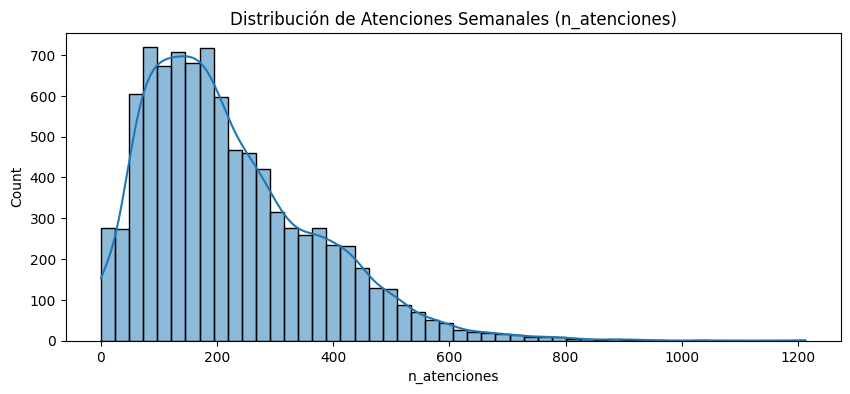

Tasa de Alta Demanda (%) por Año:
Anio
2023    25.742115
2024    21.703297
2025     18.90643
2026    32.728647
Name: alta_demanda, dtype: Float64

Correlaciones de Variables con N_Atenciones:
n_atenciones         1.000000
n_0a4                0.618354
pos_vrs              0.175586
pos_flu              0.159131
n_hosp_resp          0.130919
n_centros_vecinos   -0.358396
Name: n_atenciones, dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribución de Atenciones Totales
plt.figure(figsize=(10, 4))
sns.histplot(panel['n_atenciones'], bins=50, kde=True)
plt.title('Distribución de Atenciones Semanales (n_atenciones)')
plt.show()

# 2. Tasa de alta demanda global por año
alta_demanda_year = panel.groupby('Anio')['alta_demanda'].mean() * 100
print("Tasa de Alta Demanda (%) por Año:")
print(alta_demanda_year)

# 3. Correlación general
print("\nCorrelaciones de Variables con N_Atenciones:")
corrs = panel[['n_atenciones', 'pos_vrs', 'pos_flu', 'n_hosp_resp', 'n_0a4', 'n_centros_vecinos']].corr()['n_atenciones'].sort_values(ascending=False)
print(corrs)